# Module 6: Logistic Regression Lab
Understand and implement Logistic Regression for binary classification of a real-world dataset using Scikit-Learn Library

1. Objective:
The objective is to classify a given patient as either having breast cancer (malignant) or not having breast cancer (benign) based on a set of features extracted from medical examinations.

2. Input Features (X):
Let X be the feature vector representing a patient's medical data. These features can be quantitative measurements obtained from various diagnostic procedures. 
## DataSet Information

In this example, we will use dataset breast_cancer from Scikit-Learn Library. The features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.  
They describe characteristics of the cell nuclei present in the image.

In [1]:
# 🔧 Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc,accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
# 📥 Step 2: Load and Explore the Dataset
data = load_breast_cancer()
print(data.DESCR)


.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        worst/largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 0 is Mean Radi

In [3]:
# Convert features to a Pandas DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)

y = pd.Series(data.target) 

#Series is a one-dimensional labeled array capable of holding any data type. 
#Think of it as a single column from a spreadsheet.

print("Dataset Loaded:")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Feature names: {data.feature_names}")
print(f"Target labels: {data.target_names}\n")

X.describe()

Dataset Loaded:
Features (X) shape: (569, 30)
Target (y) shape: (569,)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target labels: ['malignant' 'benign']



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [4]:
# ⚙️ Step 3: Split and Scale the Data
# It's crucial to split your data to evaluate how well your model generalizes to unseen data.
# test_size=0.3 means 30% of the data will be used for testing.
# random_state=42 ensures reproducibility of the split.
# stratify=y ensures that the proportion of classes is the same in both training and testing sets.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

print("Data Split:")

print('{traing, Test } = {',y_train.size,y_test.size,'}')
print(f"Training features (X_train) shape: {X_train.shape}")
print(f"Testing features (X_test) shape: {X_test.shape}")
print(f"Training target (y_train) shape: {y_train.shape}")
print(f"Testing target (y_test) shape: {y_test.shape}\n")



Data Split:
{traing, Test } = { 455 114 }
Training features (X_train) shape: (455, 30)
Testing features (X_test) shape: (114, 30)
Training target (y_train) shape: (455,)
Testing target (y_test) shape: (114,)



In [5]:
# Scale the Data
# While not strictly necessary for Logistic Regression to converge,
# it's highly recommended, especially when using regularization (L1, L2 penalties)
# or when comparing coefficients, as it ensures all features contribute equally.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [7]:
# 🤖 Step 4: Train Logistic Regression Model
# We instantiate the LogisticRegression classifier.
model = LogisticRegression(max_iter=10000)

print("Logistic Regression Model Instantiated:")
print(f"Model parameters: {model.get_params()}\n")
?LogisticRegression

Logistic Regression Model Instantiated:
Model parameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 10000, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}



In [8]:
# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000)

In [9]:
# 🔍 Step 5: Evaluate the Model

# Make Predictions ---
# Predict class labels for the scaled test data
y_pred = model.predict(X_test_scaled)

print("--- Model Evaluation Results ---")

# Accuracy: The proportion of correctly classified instances.
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")


--- Model Evaluation Results ---
Accuracy: 0.9825



In [10]:
print("\n📈 Classification Report:")
print(classification_report(y_test, y_pred))
print("\n📉 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


📈 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


📉 Confusion Matrix:
[[41  1]
 [ 1 71]]


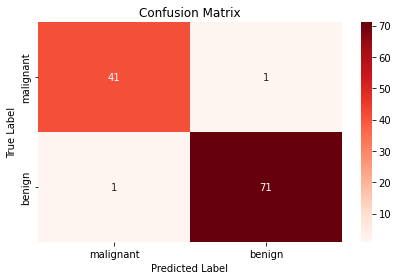

In [14]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
target_names = data.target_names

# Display confusion matrix
# Visualize the Confusion Matrix for better understanding

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

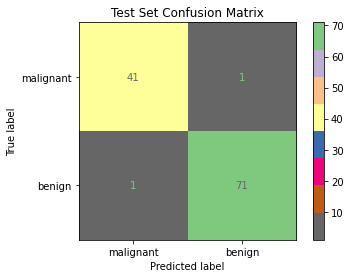

In [16]:
# Display confusion matrix using sklearn library
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=data.target_names, cmap=plt.cm.Accent_r )
plt.title("Test Set Confusion Matrix")
plt.show()

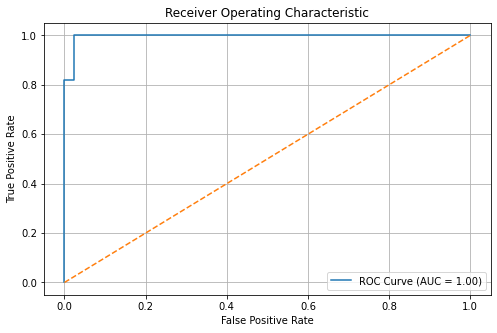

In [17]:
# 📊 Step 6: Plot ROC Curve
y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.grid(True)
plt.show()

Probability [3.35504991e-07 9.99992912e-01 1.10481356e-02 7.50730987e-01
 7.23446216e-09 9.94160102e-01 9.99994520e-01 1.43785495e-06
 1.30808623e-04 1.57802547e-10]
Predection [0 1 0 1 0 1 1 0 0 0]
true value 256    0
428    1
501    0
363    1
564    0
464    1
358    1
343    0
516    0
567    0
dtype: int32
--- Model Evaluation Results ---


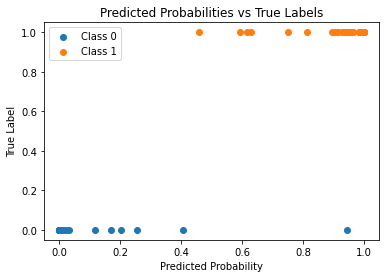

In [18]:
print('Probability',y_prob[0:10])
print('Predection',y_pred[0:10])
print('true value',y_test[0:10])
print("--- Model Evaluation Results ---")
plt.figure(figsize=(6, 4))
classes = {0,1}
for c in classes:
    indices = y_test == c
    plt.scatter(y_prob[indices], y_test[indices], label=f'Class {c}')
plt.xlabel('Predicted Probability')
plt.ylabel('True Label')
plt.title('Predicted Probabilities vs True Labels')
plt.legend()
plt.show()


In [19]:
# Save the trained model
import joblib
joblib.dump(model, 'trained_model.pkl')

['trained_model.pkl']